In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error


In [79]:
def convert_csv_to_series(data):
    pd_data=pd.read_csv(data)
    pd_series=pd_data.set_index("Date")
    cols = list(pd_series.columns)
    original_name=cols[0]
    cols[0] = 'Close'
    pd_series.columns = cols
    return pd_series,original_name

def convert_prices_to_log_return(data):
    pd_series,name=convert_csv_to_series(data)[0],convert_csv_to_series(data)[1]
    pd_series["log_returns"]=np.log(pd_series['Close'] / pd_series['Close'].shift(1))
    return pd_series["log_returns"].dropna().to_frame(),name

In [80]:
def estimate_from_data(data, dt=1/252):  
    sigma_square_hat = np.var(data, ddof=1) / dt
    sigma_hat = sigma_square_hat ** (1/2)
    mu_hat = (np.mean(data) / dt) + (sigma_square_hat / 2)  
    return mu_hat, sigma_hat

In [104]:
def simulate_prices(data_price, data_log_return, T, dt=1/252, n_simulations=10):
    mu_hat, sigma_hat = estimate_from_data(data_log_return, dt=dt)
    drift = (mu_hat - 0.5 * sigma_hat**2) * dt

    predicted = []
    S0 = float(data_price[-1])
    #np.random.seed(1)
    for _ in range(T):
        Z = np.random.normal(size=n_simulations)
        S_next = S0 * np.exp(drift + sigma_hat * np.sqrt(dt) * Z)
        S0 = np.mean(S_next) 
        predicted.append(S0)

    return np.array(predicted)

In [105]:
def final_df_test(test_data,simulated_price):
    test_data["Predicted_value"]=simulated_price
    return test_data

In [106]:
def final_result(data_log_return,data_prices,data_test):
    T=data_test.shape[0]
    
    simulated_price=simulate_prices(data_prices,data_log_return,T)
    return final_df_test(data_test,simulated_price)
    

In [107]:
def plot_predictions(data_test, title=" Stock Price Prediction"):
    
    
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    dates = pd.to_datetime(data_test["Date"])
    actual = data_test.iloc[:, 1]
    predicted = data_test["Predicted_value"]
    original_name = data_test.columns[1]
    
    
    rmse= root_mean_squared_error(actual,predicted)
    mape=mean_absolute_percentage_error(actual,predicted)*100
    
    ax.plot(dates, actual, label=f"Actual ({original_name})", color="royalblue", linewidth=2, marker='o', markersize=4)
    ax.plot(dates, predicted, label="Predicted (GBM Drift)", color="tomato", linewidth=2, linestyle="--", marker='s', markersize=4)
    
    ax.fill_between(dates, actual, predicted, alpha=0.1, color="gray", label="Prediction Error")
    
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("Date", fontsize=11)
    ax.set_ylabel("Price (₹)", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    ax.text(0.55, 0.95, f"RMSE = {rmse:.3f} \n MAPE={mape:.3f}%", 
        transform=ax.transAxes,
        verticalalignment='top',
        horizontalalignment='right',
        fontsize=12,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    plt.show()

In [108]:
sbi=convert_prices_to_log_return("sbi_main.csv")[0].to_numpy()
sbi_prices=convert_csv_to_series("sbi_main.csv")[0].to_numpy()
sbi_test=pd.read_csv("sbi_test.csv")

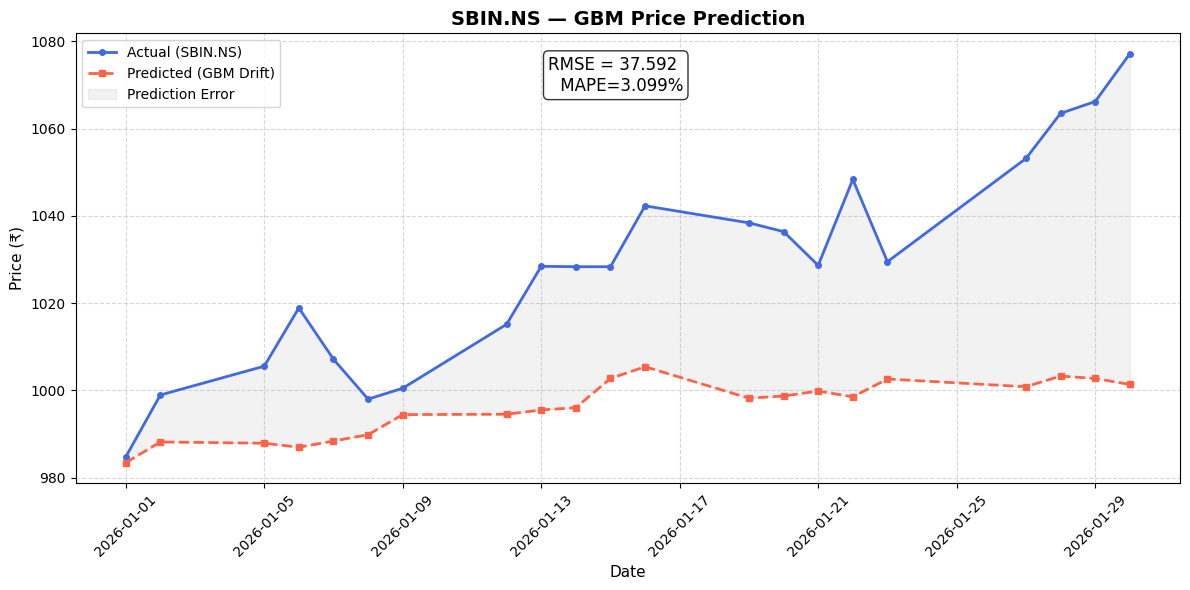

In [109]:
result = final_result(sbi, sbi_prices, sbi_test)
plot_predictions(result, title="SBIN.NS — GBM Price Prediction")

## This is clearly not working efficiently. The reasons are following: 
    1. Stock price has increased more in the month of the january than the historical pattern,
    and GBM model has failed to capture this growth. In principle, GBM is nothing but the symmetric scaled random 
    walk with drift, just for the continuous case. At the end of the day, it is just random walk, and it fails to capture 
    trends when the growth is more than the expected levels.
    
    2. We have seen that the GBM model is consistently under-predicting the future prices than the actual one, and its forecasted price remains systematically close to the initial price, S_0.
    
    3. Putting emphasis on the second point, If we incorporate the actual values instead of predicted 

## Trying some other stocks, Reliance this time

In [110]:
reliance_prices=convert_csv_to_series("reliance_main.csv")[0].to_numpy()
reliance_log_return=convert_prices_to_log_return("reliance_main.csv")[0].to_numpy()
reliance_test=pd.read_csv("reliance_test.csv")


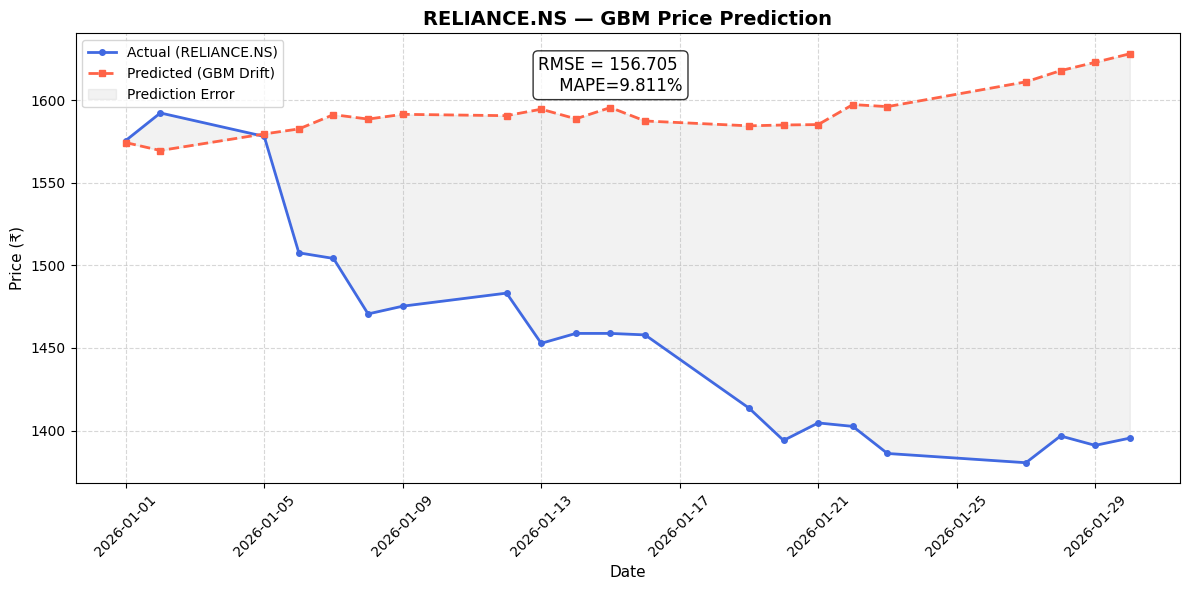

In [114]:
result_reliance = final_result(reliance_log_return, reliance_prices, reliance_test)
plot_predictions(result_reliance, title="RELIANCE.NS — GBM Price Prediction")

## Again, the classical estimation is unable to capture this sudden decline in the stock prices.

## Checking now for NIFTY 50 Index

In [115]:
nf_prices=convert_csv_to_series("nf_50_main.csv")[0].to_numpy()
nf_log_return=convert_prices_to_log_return("nf_50_main.csv")[0].to_numpy()
nf_test=pd.read_csv("nf_50_test.csv")


In [ ]:
result_nf = final_result(nf_log_return, nf_prices, nf_test)
plot_predictions(result_nf, title="NIFTY 50 — GBM Price Prediction")